In [1]:
import torch
import torch.nn as nn
import torchaudio
import torchaudio.functional as F
import soundfile as sf
import numpy as np
print(torch.__version__)
print(torchaudio.__version__)
import os
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from torch.utils.data import DataLoader, TensorDataset, random_split
import os
import pandas as pd

2.10.0+cu130
2.10.0+cu130


In [2]:
import librosa
import numpy as np

def load_audio(file_path, sr=16000):
    y, sr = librosa.load(file_path, sr=sr)
    return y

In [277]:
# def build_mimii_pump_dataframe(root_dir):
#     records = []
#     machine_path= root_dir

#     for condition in ["abnormal"]:
#         condition_path = os.path.join(machine_path, condition)

#         if not os.path.exists(condition_path):
#             continue

#         for file in os.listdir(condition_path):
#             if file.endswith(".wav"):
#                 records.append({
#                     "machine_id": "id_00",
#                     "condition": condition,
#                     "file_path": os.path.join(condition_path, file)
#                 })

#     return pd.DataFrame(records)
def build_mimii_pump_dataframe(root_dir):
    records = []

    # Loop through all machine ID folders (id_00, id_01, ...)
    for machine_id in os.listdir(root_dir):
        machine_path = os.path.join(root_dir, machine_id)

        # Skip if not a directory
        if not os.path.isdir(machine_path):
            continue

        # Only process folders that look like id_XX
        if not machine_id.startswith("id_"):
            continue

        # Process abnormal folder (change to ["normal", "abnormal"] if needed)
        condition = "abnormal"
        condition_path = os.path.join(machine_path, condition)

        if not os.path.exists(condition_path):
            continue

        for file in os.listdir(condition_path):
            if file.endswith(".wav"):
                records.append({
                    "machine_id": machine_id,
                    "condition": condition,
                    "file_path": os.path.join(condition_path, file)
                })

    return pd.DataFrame(records)

In [278]:
root_dir = r"data\0_dB_pump\pump"
df = build_mimii_pump_dataframe(root_dir)

print(df.head())
print(df["condition"].value_counts())

  machine_id condition                                        file_path
0      id_00  abnormal  data\0_dB_pump\pump\id_00\abnormal\00000000.wav
1      id_00  abnormal  data\0_dB_pump\pump\id_00\abnormal\00000001.wav
2      id_00  abnormal  data\0_dB_pump\pump\id_00\abnormal\00000002.wav
3      id_00  abnormal  data\0_dB_pump\pump\id_00\abnormal\00000003.wav
4      id_00  abnormal  data\0_dB_pump\pump\id_00\abnormal\00000004.wav
condition
abnormal    456
Name: count, dtype: int64


In [6]:
df["label"] = df["condition"].map({"normal": 0, "abnormal": 1})

In [4]:
import torch
import librosa
import numpy as np
from transformers import ASTFeatureExtractor, ASTModel

# Load pretrained AST
feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)
model = ASTModel.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ASTModel(
  (embeddings): ASTEmbeddings(
    (patch_embeddings): ASTPatchEmbeddings(
      (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ASTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ASTLayer(
        (attention): ASTAttention(
          (attention): ASTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ASTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ASTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ASTOutput(
          (d

In [279]:
def extract_embeddings(audio_path):    
    waveform, sr = librosa.load(audio_path, sr=16000)

    inputs = feature_extractor(
        waveform,
        sampling_rate=16000,
        return_tensors="pt"
    )
    with torch.no_grad():
        outputs = model(**inputs)

    # CLS token embedding
    embedding = outputs.last_hidden_state[:, 0, :]
    return embedding  # (1, 768)

In [280]:
embeddings = []
for file in df['file_path']:
    embedding = extract_embeddings(file) # (1, 768)
    embeddings.append(embedding.squeeze().numpy())

X = np.vstack(embeddings)

In [332]:
machine_stats = {}

for m in np.unique(df['machine_id']):
    idx = (df['machine_id'] == m)
    mu = X[idx].mean(axis=0)
    sigma = X[idx].std(axis=0)
    machine_stats[m] = (mu, sigma)
X_norm=X.copy()
for i, m in enumerate(df['machine_id']):
    mu, sigma = machine_stats[m]
    X_norm[i] = (X[i] - mu) / (sigma + 1e-8)

In [333]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

In [334]:
from sklearn.manifold import trustworthiness
import umap
from sklearn.decomposition import PCA
X_pca2 = PCA(n_components=2).fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2)
X_umap2 = reducer.fit_transform(X_scaled)

print("PCA trust:", trustworthiness(X_scaled, X_pca2))
print("UMAP trust:", trustworthiness(X_scaled, X_umap2))

PCA trust: 0.8313312578320802
UMAP trust: 0.9309895833333334


In [335]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA().fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)

d_star = np.argmax(cum_var >= 0.95)
print("Approx intrinsic dimension:", d_star)

Approx intrinsic dimension: 143


In [404]:
from sklearn.manifold import trustworthiness
import umap
D=[2, 5, 10,15, 20, 30,40]
trusts=[]
for d in D:
    reducer = umap.UMAP(n_components=d)
    X_red = reducer.fit_transform(X_scaled)
    score = trustworthiness(X_scaled, X_red)
    trusts.append(score)
    print(d, score)


2 0.9270099075814536
5 0.9457178101503759
10 0.9518973214285714
15 0.9507097822681704
20 0.9474859022556391
30 0.9507352365288221
40 0.9483170817669173


In [405]:
import hdbscan
from sklearn.metrics import silhouette_score
scores=[]
for d in D:
    reducer = umap.UMAP(n_components=d)
    X_red = reducer.fit_transform(X_scaled)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=30)
    labels = clusterer.fit_predict(X_red)

    if len(set(labels)) > 1:
        score = silhouette_score(X_red[labels!=-1], labels[labels!=-1])
        scores.append(score)
        print(d, score)

2 0.6424529552459717
5 0.6581286191940308
10 0.8367135524749756
15 0.8604932427406311
20 0.5592964291572571
30 0.8535405397415161
40 0.8257167339324951


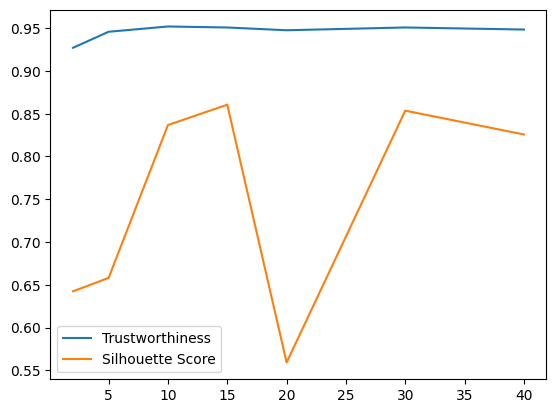

In [428]:
plt.plot(D,trusts,label='Trustworthiness')
plt.plot(D,scores,label='Silhouette Score')
plt.legend()

In [449]:
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
p=0.8
n_9 = np.argmax(cum_var >= p) + 1
print(f"Components for {p*100}% variance:", n_9)

Components for 80.0% variance: 44


In [208]:
pca_full.explained_variance_.shape

(143,)

In [450]:
pca = PCA(n_components=n_9)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(456, 44)


In [ ]:
import umap

reducer = umap.UMAP(
    #n_neighbors=10, # defines the size of the local neighborhood UMAP considers when learning the manifold structure of the data
    #min_dist=0.3, # controls how tightly UMAP packs points together
    n_components=20   # using >2 for clustering stability
)

X_umap = reducer.fit_transform(X_scaled)

In [451]:
for n in [10,20,30,50,60,90,100]:
    for m in [0.1,0.3,0.5,0.8]:
        print("X"*90)
        reducer = umap.UMAP(
            n_neighbors=n, # defines the size of the local neighborhood UMAP considers when learning the manifold structure of the data
            min_dist=m, # controls how tightly UMAP packs points together
            n_components=20   # using >2 for clustering stability
        )

        X_umap = reducer.fit_transform(X_scaled)

        print(f"n_neighbours:{n} min_dist:{m}")
        for mcs in [5,10,15,20,25,30 ,40, 60]:
            for ms in [5,10,15, 20, 40]:
                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=mcs,
                    min_samples=ms
                )
                labels = clusterer.fit_predict(X_umap)

                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                noise_ratio = (labels == -1).mean()
                if noise_ratio==0.0:
                    print(mcs, ms, n_clusters, noise_ratio)
                    unique_clusters = np.unique(labels)

                    for c in unique_clusters:
                        count = np.sum(labels == c)
                        print(f"Cluster {c}: {count} samples")

                    mask = labels != -1
                    X_clean = X_pca[mask]
                    labels_clean = labels[mask]

                    unique_clusters = np.unique(labels_clean)

                    centroids = {}
                    for c in unique_clusters:
                        centroids[c] = X_clean[labels_clean == c].mean(axis=0)

                    within_variance = {}

                    for c in unique_clusters:
                        points = X_clean[labels_clean == c]
                        centroid = centroids[c]
                        sq_dist = np.sum((points - centroid)**2, axis=1)
                        within_variance[c] = np.mean(sq_dist)

                    from itertools import combinations

                    between_distances = []

                    for c1, c2 in combinations(unique_clusters, 2):
                        dist = np.linalg.norm(centroids[c1] - centroids[c2])
                        between_distances.append(dist)

                    mean_between = np.mean(between_distances)
                    mean_within = np.mean(list(within_variance.values()))

                    separation_ratio = mean_between / mean_within

                    print("Mean between distance:", mean_between)
                    print("Mean within variance:", mean_within)
                    print("Separation ratio:", separation_ratio)
                    from sklearn.metrics import silhouette_score
                    print("="*30)

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
n_neighbours:10 min_dist:0.1
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
n_neighbours:10 min_dist:0.3
5 5 3 0.0
Cluster 0: 31 samples
Cluster 1: 15 samples
Cluster 2: 410 samples
Mean between distance: 30.159378
Mean within variance: 324.50525
Separation ratio: 0.09293957
5 10 3 0.0
Cluster 0: 31 samples
Cluster 1: 15 samples
Cluster 2: 410 samples
Mean between distance: 30.159378
Mean within variance: 324.50525
Separation ratio: 0.09293957
5 15 2 0.0
Cluster 0: 31 samples
Cluster 1: 425 samples
Mean between distance: 25.018858
Mean within variance: 390.8313
Separation ratio: 0.06401447
10 5 3 0.0
Cluster 0: 31 samples
Cluster 1: 15 samples
Cluster 2: 410 samples
Mean between distance: 30.159378
Mean within variance: 324.50525
Separation ratio: 0.09293957
10 10 3 0.0
Cluster 0: 31 samples
Cluster 1: 15 samples
Cluster 2: 410 samples
Mean between dist

In [461]:
reducer = umap.UMAP(
    n_neighbors=15, # defines the size of the local neighborhood UMAP considers when learning the manifold structure of the data
    min_dist=0.5, # controls how tightly UMAP packs points together
    n_components=20   # using >2 for clustering stability
)

X_umap = reducer.fit_transform(X_scaled)

In [462]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5
)

cluster_labels = clusterer.fit_predict(X_umap)

In [463]:
import numpy as np

unique_clusters = np.unique(cluster_labels)
print("Clusters found:", unique_clusters)

for c in unique_clusters:
    count = np.sum(cluster_labels == c)
    print(f"Cluster {c}: {count} samples")

Clusters found: [0 1]
Cluster 0: 31 samples
Cluster 1: 425 samples


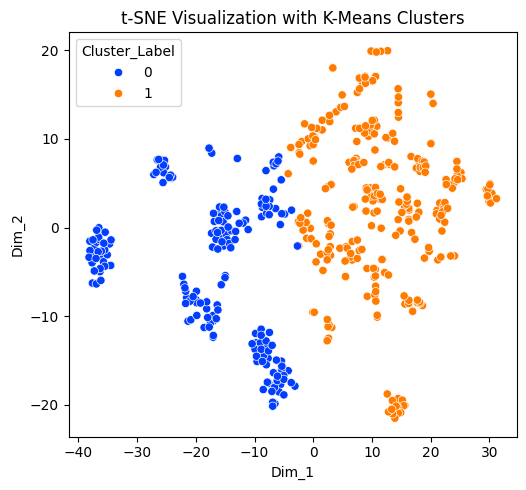

In [464]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris




tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
mask = cluster_labels != -1
X_clean = X_pca[mask]
X_tsne = tsne.fit_transform(X_clean)


kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_tsne)


tsne_df = pd.DataFrame(data=X_tsne, columns=['Dim_1', 'Dim_2'])
tsne_df['Cluster_Label'] = clusters


plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
sn.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue='Cluster_Label', palette='bright')
plt.title('t-SNE Visualization with K-Means Clusters')



plt.tight_layout()
plt.show()
